In [35]:
import numpy as np
from pygmid import Lookup as lk
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm

# Load technology data
NCH = lk('../../sky130_lookup/simulation/nfet_01v8.mat')
PCH = lk('../../sky130_lookup/simulation/pfet_01v8.mat')

In [36]:
# ===================
# 5T-OTA DESIGN SPECS
# ===================
VDD = 1.8                           # Supply Voltage (V)
CL  = 2e-12                         # Load Capacitance (F)
SR_spec = 1e6                       # Slew Rate (V/s)
GBW_spec = 1e6                      # Gain Bandwidth (Hz)
Gain_spec_dB = 38                   # DC Gain (dB)
Gain_spec = 10**(Gain_spec_dB/20)   # Convert dB to V/V
PM_spec = 65                        # Phase Margin (degrees)
Power_spec = 10e-6                  # Power Consumption (W)

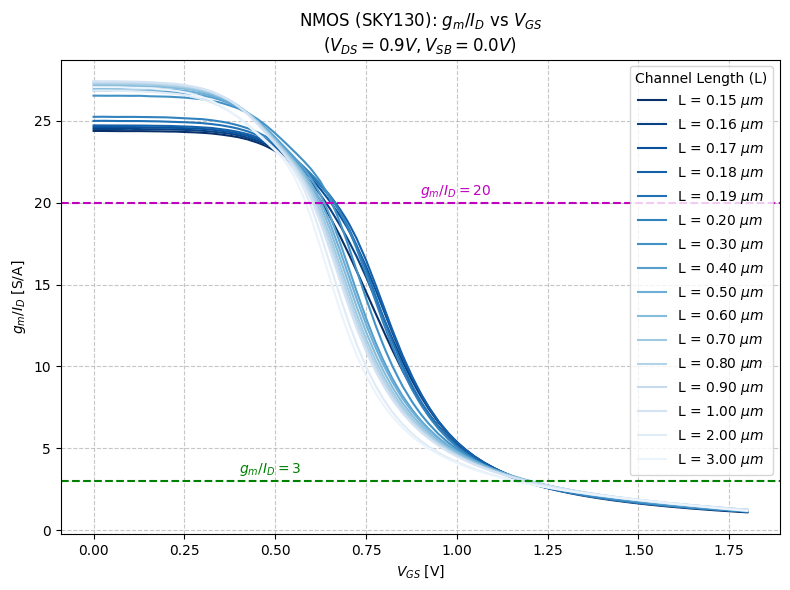

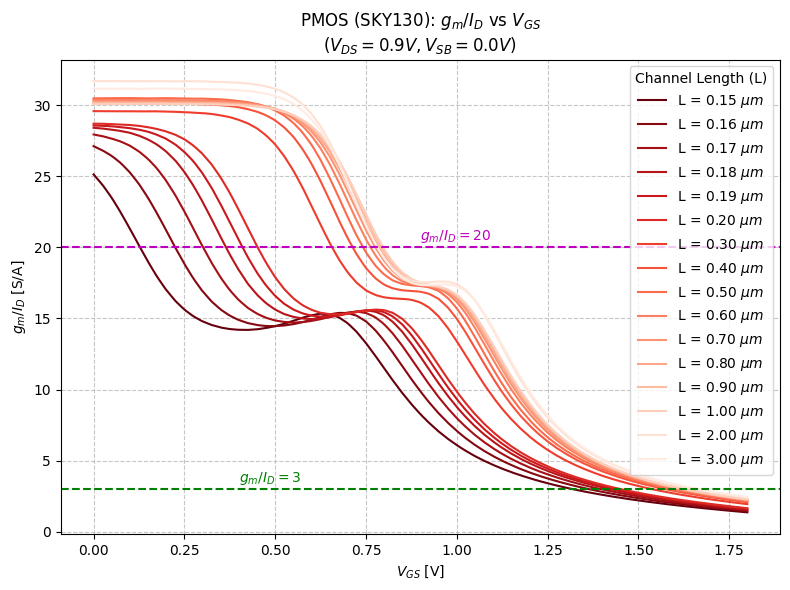

In [37]:
# ==============================
# NMOS & PMOS gm/ID VS VGS PLOTS
# ==============================
# Define Sweep Parameters
VGS_sweep = np.linspace(0, VDD, 200) 
VDS_const = VDD/2  # Set VDS to mid-rail
VSB_const = 0.0  # Source-Bulk voltage

def plot_gmid_vs_vgs(device_data, device_name, color_map):
    plt.figure(figsize=(8, 6))
    
    # Extract all available Lengths from the LUT
    L_values = np.unique(device_data['L'])

    # Loop through each 'L' and plot
    for i, L_val in enumerate(L_values):
        # Look up 'GM_ID' while sweeping VGS, holding L, VDS, and VSB constant
        gm_ID = device_data.lookup('GM_ID', vgs=VGS_sweep, VDS=VDS_const, VSB=VSB_const, L=L_val)
        
        # Plotting
        plt.plot(VGS_sweep, gm_ID, label=rf'L = {L_val:.2f} $\mu m$', color=color_map(i / len(L_values)))

    # Formatting the Plot
    plt.title(f'{device_name}: $g_m/I_D$ vs $V_{{GS}}$\n($V_{{DS}}={VDS_const}V, V_{{SB}}={VSB_const}V$)')
    plt.xlabel('$V_{GS}$ [V]')
    plt.ylabel('$g_m/I_D$ [S/A]')

    # Upper bound for gm/ID axis
    plt.axhline(y=20, color='m', linestyle='--')
    plt.text(0.9, 20.5, '$g_m/I_D = 20$', color='m')
    # Lower bound for gm/ID axis
    plt.axhline(y=3, color='g', linestyle='--')
    plt.text(0.4, 3.5, '$g_m/I_D = 3$', color='g')

    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1, 1), loc='upper right', title="Channel Length (L)")
    plt.tight_layout()
    plt.show()

# Generate Plots
plot_gmid_vs_vgs(NCH, "NMOS (SKY130)", plt.cm.Blues_r)
plot_gmid_vs_vgs(PCH, "PMOS (SKY130)", plt.cm.Reds_r)

In [38]:
# ===============================
# LUT FOR DIODE CONNECTED DEVICES
# ===============================
vgs_sweep = np.arange(0.05, VDD+0.1, 0.01)

# Function to create diode-connected LUT
def diode_connected_lut(device_data, vgs_sweep):
    L_values = np.unique(device_data['L'])
    diode_lut = {}

    for l_val in L_values:
        gm_id = device_data.lookup('GM_ID', L=l_val, VGS=vgs_sweep, VDS=vgs_sweep, VSB=0)
        diode_lut[l_val] = np.diag(gm_id)

    return diode_lut

# Create LUTs for diode-connected NMOS and PMOS
nch_results = diode_connected_lut(NCH, vgs_sweep)
pch_results = diode_connected_lut(PCH, vgs_sweep)

# Function to get VGS for a target gm/ID
def getVGS_diode(device_type, target_gm_id, length):
    if device_type.lower() == 'nmos':
        gm_id_vec = nch_results[length]
    elif device_type.lower() == 'pmos':
        gm_id_vec = pch_results[length]
    else:
        raise ValueError("Device type must be 'nmos' or 'pmos'.")

    get_vgs = interp1d(gm_id_vec, vgs_sweep, kind='linear', bounds_error=False)
    vgs_required = get_vgs(target_gm_id)
    return vgs_required

In [39]:
# =========================================
# INPUT DESIGN PARAMETERS FOR 5T-OTA SIZING
# =========================================
I_tail_min = SR_spec * CL  # Minimum tail current (A)
print(f"Minimum Tail Current (I_tail_min) for SR = {SR_spec*1e-6:.2f}V/μs and CL = {CL*1e12:.2f}pF : {I_tail_min*1e6:.2f}μA")

I_tail_max = np.floor(Power_spec * 1e7 / VDD) / 1e7  # Maximum tail current (A)
print(f"Maximum Tail Current (I_tail_max) for Power = {Power_spec*1e6:.2f}μW and VDD = {VDD:.2f}V : {I_tail_max*1e6:.2f}μA")

gm1_min = 2 * np.pi * GBW_spec * CL  # Minimum gm1 for GBW spec
print(f"Minimum gm1 (gm1_min) for GBW = {GBW_spec*1e-6:.2f}MHz and CL = {CL*1e12:.2f}pF : {gm1_min*1e6:.2f}μS")

gm_ID_range = np.linspace(3, 20, 18)  # gm/ID range (S/A)
L_N_range = np.unique(NCH['L'])  # L values for NMOS (um)
L_P_range = np.unique(PCH['L'])  # L values for PMOS (um)
ID_factor_range = np.linspace(1, I_tail_max/I_tail_min, 176)  # Margin factor range

Minimum Tail Current (I_tail_min) for SR = 1.00V/μs and CL = 2.00pF : 2.00μA
Maximum Tail Current (I_tail_max) for Power = 10.00μW and VDD = 1.80V : 5.50μA
Minimum gm1 (gm1_min) for GBW = 1.00MHz and CL = 2.00pF : 12.57μS


In [40]:
def vgs_error(vgs_guess, target_gm_id, L, VSB):  # VGS solver function
    vgs_calculated = PCH.lookupVGS(GM_ID=target_gm_id, VDS=vgs_guess, VSB=VSB, L=L)
    return vgs_guess - vgs_calculated

In [41]:
# # ====================================
# # BRUTE FORCE DESIGN SPACE EXPLORATION
# # ====================================
# ID_factor_results = []
# gm_ID_1_results = []
# gm_ID_2_results = []
# L_1_results = []
# L_2_results = []
# Area_active_results = []

# total_iterations = (len(ID_factor_range) * len(gm_ID_range) * len(gm_ID_range) * len(L_N_range) * len(L_P_range))

# with tqdm(total=total_iterations, desc="Total Progress") as pbar:
#     for ID_factor in ID_factor_range:
#         for gm_ID_1 in gm_ID_range:
#             for gm_ID_2 in gm_ID_range:
#                 for L_1 in L_N_range:
#                     for L_2 in L_P_range:
#                         pbar.update(1)
#                         # ==============================
#                         # TRANSISTOR SIZING CALCULATIONS
#                         # ==============================
#                         ID_12 = (I_tail_min / 2) * ID_factor  # With a margin factor for tail current split

#                         # Power Consumption Verification
#                         Power_calc = ID_12 * 2 * VDD
#                         if Power_calc > Power_spec: continue

#                         # gm1 Verification
#                         gm1 = gm_ID_1 * ID_12
#                         if gm1 < gm1_min: continue

#                         gm2 = gm_ID_2 * ID_12

#                         Vgs_2 = brentq(vgs_error, 0.05, 1.8, args=(gm_ID_2, L_2, 0))

#                         Cdd_1 = gm1 / NCH.lookup('GM_CDD', GM_ID=gm_ID_1, VDS=VDD/2, VSB=0, L=L_1)
#                         Cdd_2 = gm2 / PCH.lookup('GM_CDD', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)
#                         Cpar = Cdd_1 + Cdd_2                

#                         Cgg_2 = gm2 / PCH.lookup('GM_CGG', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)
#                         Cx = Cpar + Cgg_2

#                         JD_1 = NCH.lookup('ID_W', GM_ID=gm_ID_1, VDS=VDD/2, VSB=0, L=L_1)
#                         JD_2 = PCH.lookup('ID_W', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)

#                         W_1 = ID_12 / JD_1
#                         W_2 = ID_12 / JD_2

#                         # Width Verification
#                         if W_1 < 0.42 or W_2 < 0.42: continue

#                         # ==================
#                         # SPECS VERIFICATION
#                         # ==================
#                         Cload_total = CL + Cpar

#                         # Slew Rate Verification
#                         SR_calc = (ID_12 * 2) / Cload_total
#                         if SR_calc < SR_spec: continue

#                         # Gain Bandwidth Verification
#                         GBW_calc = gm1 / (2 * np.pi * Cload_total)
#                         if GBW_calc < GBW_spec: continue

#                         # Phase Margin (degrees) Verification
#                         PM_calc = 90 - (np.arctan(GBW_calc / (gm2 / Cx))*(180/np.pi))
#                         if PM_calc < PM_spec: continue

#                         gds_1 = gm1 / NCH.lookup('GM_GDS', GM_ID=gm_ID_1, VDS=VDD/2, VSB=0, L=L_1)
#                         gds_2 = gm2 / PCH.lookup('GM_GDS', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)

#                         # Gain Verification
#                         Gain_calc = gm1 / (gds_1 + gds_2)
#                         if Gain_calc < Gain_spec: continue

#                         # Active area calculation
#                         Area_active = 2 * ((W_1 * L_1) + (W_2 * L_2))

#                         # If all specs are met, save to a list
#                         ID_factor_results.append(ID_factor)
#                         gm_ID_1_results.append(gm_ID_1)
#                         gm_ID_2_results.append(gm_ID_2)
#                         L_1_results.append(L_1)
#                         L_2_results.append(L_2)
#                         Area_active_results.append(Area_active)

In [42]:
# ====================================
# BRUTE FORCE DESIGN SPACE EXPLORATION
# ====================================
ID_factor_results = []
gm_ID_1_results = []
gm_ID_2_results = []
L_1_results = []
L_2_results = []
Area_active_results = []

total_iterations = (len(ID_factor_range) * len(gm_ID_range) * len(gm_ID_range) * len(L_N_range) * len(L_P_range))

weight_L_P = len(L_P_range)
weight_gm_ID_2 = len(gm_ID_range) * weight_L_P
weight_L_N = len(L_N_range) * weight_gm_ID_2
weight_gm_ID_1 = len(gm_ID_range) * weight_L_N

with tqdm(total=total_iterations, desc="Total Progress") as pbar:
    for ID_factor in ID_factor_range:
        ID_12 = (I_tail_min / 2) * ID_factor  # With a margin factor for tail current split
        # Power Consumption Verification
        Power_calc = ID_12 * 2 * VDD
        if Power_calc > Power_spec:
            pbar.update(weight_gm_ID_1)
            continue

        for gm_ID_1 in gm_ID_range:
            # gm1 Verification
            gm1 = gm_ID_1 * ID_12
            if gm1 < gm1_min:
                pbar.update(weight_L_N)
                continue
            
            for L_1 in L_N_range:
                JD_1 = NCH.lookup('ID_W', GM_ID=gm_ID_1, VDS=VDD/2, VSB=0, L=L_1)
                W_1 = ID_12 / JD_1
                # Width 1 Verification
                if W_1 < 0.42:
                    pbar.update(weight_gm_ID_2)
                    continue
                Cdd_1 = gm1 / NCH.lookup('GM_CDD', GM_ID=gm_ID_1, VDS=VDD/2, VSB=0, L=L_1)
                gds_1 = gm1 / NCH.lookup('GM_GDS', GM_ID=gm_ID_1, VDS=VDD/2, VSB=0, L=L_1)

                for gm_ID_2 in gm_ID_range:
                    gm2 = gm_ID_2 * ID_12
                
                    for L_2 in L_P_range:
                        pbar.update(1)
                        Vgs_2 = getVGS_diode('PMOS', gm_ID_2, L_2)
                        JD_2 = PCH.lookup('ID_W', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)
                        W_2 = ID_12 / JD_2
                        # Width 2 Verification
                        if W_2 < 0.42: continue

                        Cdd_2 = gm2 / PCH.lookup('GM_CDD', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)
                        Cpar = Cdd_1 + Cdd_2                

                        Cgg_2 = gm2 / PCH.lookup('GM_CGG', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)
                        Cx = Cpar + Cgg_2

                        Cload_total = CL + Cpar

                        # Slew Rate Verification
                        SR_calc = (ID_12 * 2) / Cload_total
                        if SR_calc < SR_spec: continue

                        # Gain Bandwidth Verification
                        GBW_calc = gm1 / (2 * np.pi * Cload_total)
                        if GBW_calc < GBW_spec: continue

                        # Phase Margin (degrees) Verification
                        PM_calc = 90 - (np.arctan(GBW_calc / (gm2 / Cx))*(180/np.pi))
                        if PM_calc < PM_spec: continue
                        
                        gds_2 = gm2 / PCH.lookup('GM_GDS', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)
                        # Gain Verification
                        Gain_calc = gm1 / (gds_1 + gds_2)
                        if Gain_calc < Gain_spec: continue

                        # Active area calculation
                        Area_active = 2 * ((W_1 * L_1) + (W_2 * L_2))

                        # If all specs are met, save to a list
                        ID_factor_results.append(ID_factor)
                        gm_ID_1_results.append(gm_ID_1)
                        gm_ID_2_results.append(gm_ID_2)
                        L_1_results.append(L_1)
                        L_2_results.append(L_2)
                        Area_active_results.append(Area_active)

Total Progress:  24%|██▍       | 3467377/14598144 [3:00:13<9:38:32, 320.65it/s] 


KeyboardInterrupt: 

In [43]:
# Save results to a text file
with open('5T_OTA_Brute_Force_Results.txt', 'w') as f:
    f.write("ID_factor,gm_ID_1,gm_ID_2,L_1,L_2,Area_active\n")
    for i in range(len(Area_active_results)):
        f.write(f"{ID_factor_results[i]},{gm_ID_1_results[i]},{gm_ID_2_results[i]},{L_1_results[i]},{L_2_results[i]},{Area_active_results[i]}\n")

In [44]:
print(f"Number of Valid Configurations Found: {len(Area_active_results)}\n")

# Find index of minimum active area
min_area_index = np.argmin(Area_active_results)
print(f"Minimum Active Area Configuration:")
print("----------------------------------")
print(f"ID_factor: {ID_factor_results[min_area_index]}")
print(f"gm_ID_1: {gm_ID_1_results[min_area_index]}")
print(f"gm_ID_2: {gm_ID_2_results[min_area_index]}")
print(f"L_1: {L_1_results[min_area_index]}")
print(f"L_2: {L_2_results[min_area_index]}")

Number of Valid Configurations Found: 260332

Minimum Active Area Configuration:
----------------------------------
ID_factor: 1.32
gm_ID_1: 14.0
gm_ID_2: 9.0
L_1: 0.6
L_2: 0.5


In [45]:
ID_factor = ID_factor_results[min_area_index]
gm_ID_1 = gm_ID_1_results[min_area_index]
gm_ID_2 = gm_ID_2_results[min_area_index]
L_1 = L_1_results[min_area_index]
L_2 = L_2_results[min_area_index]

# ==============================
# OPTIMIZED SIZING CALCULATIONS
# ==============================
ID_12 = (I_tail_min / 2) * ID_factor  # With a margin factor for tail current split
print(f"Design Tail Current (ID_tail) : {ID_12*1e6*2:.2f}μA\n")

gm1 = gm_ID_1 * ID_12
gm2 = gm_ID_2 * ID_12
print(f"Calculated gm1: {gm1*1e6:.2f}μS")
print(f"Calculated gm2: {gm2*1e6:.2f}μS")

Vgs_1 = NCH.lookupVGS(GM_ID=gm_ID_1, VDS=VDD/2, VSB=0, L=L_1)
print(f"NMOS M1 Vgs at gm/ID={gm_ID_1}S/A and L={L_1}μm : {Vgs_1:.3f}V")

Vgs_2 = PCH.lookupVGS(GM_ID=gm_ID_2, VSB=0, L=L_2)
for i in range(5):
    Vgs_2 = PCH.lookupVGS(GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)
print(f"PMOS M2 Vgs at gm/ID={gm_ID_2}S/A and L={L_2}μm : {Vgs_2:.3f}V")

Cdd_1 = gm1 / NCH.lookup('GM_CDD', GM_ID=gm_ID_1, VDS=VDD/2, VSB=0, L=L_1)
Cdd_2 = gm2 / PCH.lookup('GM_CDD', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)
Cpar = Cdd_1 + Cdd_2
print(f"Parasitic Capacitance at Output Node (Cpar) : {Cpar*1e15:.2f}fF")
Cload_total = CL + Cpar

Cgg_2 = gm2 / PCH.lookup('GM_CGG', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)
Cx = Cpar + Cgg_2

JD_1 = NCH.lookup('ID_W', GM_ID=gm_ID_1, VDS=VDD/2, VSB=0, L=L_1)
JD_2 = PCH.lookup('ID_W', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)

W_1 = ID_12 / JD_1
print(f"\nNMOS M1 Width (W1) : {W_1:.2f}μm")

W_2 = ID_12 / JD_2
print(f"PMOS M2 Width (W2) : {W_2:.2f}μm\n")

gds_1 = gm1 / NCH.lookup('GM_GDS', GM_ID=gm_ID_1, VDS=VDD/2, VSB=0, L=L_1)
gds_2 = gm2 / PCH.lookup('GM_GDS', GM_ID=gm_ID_2, VDS=Vgs_2, VSB=0, L=L_2)

Vth_1 = NCH.lookup('VT', VGS=Vgs_1, VDS=VDD/2, VSB=0, L=L_1)
print(f"NMOS M1 Threshold Voltage (Vth_1) : {Vth_1:.3f}V")

Vth_2 = PCH.lookup('VT', VGS=Vgs_2, VDS=Vgs_2, VSB=0, L=L_2)
print(f"PMOS M2 Threshold Voltage (Vth_2) : {Vth_2:.3f}V")

# ========================
# FINAL SPECS VERIFICATION
# ========================

# Slew Rate Verification
SR_calc = (ID_12 * 2) / Cload_total
print(f"\nCalculated Slew Rate (SR_calc = {SR_calc*1e-6:.2f}V/μs)")

# Gain Bandwidth Verification
GBW_calc = gm1 / (2 * np.pi * Cload_total)
print(f"Calculated Gain Bandwidth (GBW_calc = {GBW_calc*1e-6:.2f}MHz)")

# Gain Verification
Gain_calc = gm1 / (gds_1 + gds_2)
print(f"Calculated Gain (Gain_calc = {20*np.log10(Gain_calc):.2f}dB)")

# Phase Margin (degrees) Verification
PM_calc = 90 - (np.arctan(GBW_calc / (gm2 / Cpar))*(180/np.pi))
print(f"Calculated Phase Margin (PM_calc = {PM_calc:.2f} degrees)")

# Power Consumption Verification
Power_calc = ID_12 * 2 * VDD
print(f"Calculated Power Consumption (Power_calc = {Power_calc*1e6:.2f}μW)")

# Active area calculation
Area_active = 2 * ((W_1 * L_1) + (W_2 * L_2))
print(f"\nTotal Active Area of 5T-OTA : {Area_active:.2f}μm²")

Design Tail Current (ID_tail) : 2.64μA

Calculated gm1: 18.48μS
Calculated gm2: 11.88μS
NMOS M1 Vgs at gm/ID=14.0S/A and L=0.6μm : 0.719V
PMOS M2 Vgs at gm/ID=9.0S/A and L=0.5μm : 1.162V
Parasitic Capacitance at Output Node (Cpar) : 0.49fF

NMOS M1 Width (W1) : 0.42μm
PMOS M2 Width (W2) : 0.45μm

NMOS M1 Threshold Voltage (Vth_1) : 0.618V
PMOS M2 Threshold Voltage (Vth_2) : 0.981V

Calculated Slew Rate (SR_calc = 1.32V/μs)
Calculated Gain Bandwidth (GBW_calc = 1.47MHz)
Calculated Gain (Gain_calc = 38.99dB)
Calculated Phase Margin (PM_calc = 90.00 degrees)
Calculated Power Consumption (Power_calc = 4.75μW)

Total Active Area of 5T-OTA : 0.95μm²
